In [72]:
from langgraph.graph import StateGraph, MessagesState, START, END
from langchain_community.document_loaders import WebBaseLoader
import getpass
import os
from langchain_text_splitters import RecursiveCharacterTextSplitter
import tiktoken
from dotenv import load_dotenv
load_dotenv()

True

# FETCH DOCUMENT USING THE DOCUMENT LOADER 

In [73]:
urls = [
    "https://lilianweng.github.io/posts/2024-11-28-reward-hacking/",
    "https://lilianweng.github.io/posts/2024-07-07-hallucination/",
    "https://lilianweng.github.io/posts/2024-04-12-diffusion-video/",
]

docs = [WebBaseLoader(url).load() for url in urls]
docs[0][0].page_content.strip()[:1000]

"Reward Hacking in Reinforcement Learning | Lil'Log\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\nLil'Log\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n|\n\n\n\n\n\n\nPosts\n\n\n\n\nArchive\n\n\n\n\nSearch\n\n\n\n\nTags\n\n\n\n\nFAQ\n\n\n\n\n\n\n\n\n\n      Reward Hacking in Reinforcement Learning\n    \nDate: November 28, 2024  |  Estimated Reading Time: 37 min  |  Author: Lilian Weng\n\n\n \n\n\nTable of Contents\n\n\n\nBackground\n\nReward Function in RL\n\nSpurious Correlation\n\n\nLet’s Define Reward Hacking\n\nList of Examples\n\nReward hacking examples in RL tasks\n\nReward hacking examples in LLM tasks\n\nReward hacking examples in real life\n\n\nWhy does Reward Hacking Exist?\n\n\nHacking RL Environment\n\nHacking RLHF of LLMs\n\nHacking the Training Process\n\nHacking the Evaluator\n\nIn-Context Reward Hacking\n\n\nGeneralization of Hacking Skills\n\nPeek into Mitigations\n\nRL Algorithm Improvement\n\nDetecting Reward Hacking\n\nData Analysis of RLHF\

# SPLIT THE DOCUMENTS INTO CHUNKS

In [74]:
docs_list = [item for sublist in docs for item in sublist]

text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    chunk_size = 100, chunk_overlap = 50
)
docs_chunks = text_splitter.split_documents(docs_list)

docs_chunks[0].page_content.strip()[:500]

"Reward Hacking in Reinforcement Learning | Lil'Log\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\nLil'Log\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n|\n\n\n\n\n\n\nPosts\n\n\n\n\nArchive\n\n\n\n\nSearch\n\n\n\n\nTags\n\n\n\n\nFAQ"

# INDEXING IN VECTOR STORE FOR SEMANTIC SEARCH

In [ ]:
from langchain_core.vectorstores import InMemoryVectorStore
from langchain_huggingface import HuggingFaceEmbeddings

vector_store = InMemoryVectorStore.from_documents(
    documents = docs_chunks,
    embedding = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2"),
)


# RETREIVER FOR SEMANTIC SEARCH

In [76]:
retriever = vector_store.as_retriever()

# USING LANGCHAIN PREBUILT RETRIEVER TOOL

In [77]:
from langchain_core.tools import tool

@tool
def retrieve_blog_posts(query: str) -> str:
    """Search and return information about Lilian Weng blog posts."""
    docs = retriever.invoke(query)
    return "\n\n".join(doc.page_content for doc in docs)

# Assign to retriever_tool for consistency with rest of notebook
retriever_tool = retrieve_blog_posts

found_text = retriever_tool.invoke({"query": "types of hallucinations"})

In [78]:
# from langchain_classic.tools.retriever import create_retriever_tool

# retriever_tool = create_retriever_tool(
#     retriever = retriever,
#     name = "retrieve_blog_posts",
#     description = "Search and return information about Lilian Weng blog posts.",
# )

# found_text = retriever_tool.invoke({"query": "types of hallucinations"})

# BUILDING NODE

In [79]:
from langgraph.graph import MessagesState
from langchain.chat_models import init_chat_model
from langchain_groq import ChatGroq

GEMINI_API_KEY = os.getenv("GEMINI_API_KEY")
GOOGLE_API = os.getenv("GOOGLE_API_KEY")
GROQ_API_KEY = os.getenv("GROQ")

In [81]:
# response_model = init_chat_model("google_genai:gemini-2.0-flash-lite", max_retries = 2, timeout = 60, api_key = GEMINI_API_KEY)

# response_model = ChatGoogleGenerativeAI(
#     model = "gemini-2.0-flash-lite",
#     api_key = GEMINI_API_KEY
# )

response_model = ChatGroq(
    api_key = GROQ_API_KEY,
    model = "openai/gpt-oss-20b"
)

In [82]:
def generate_query_or_respond(state: MessagesState) -> str:
    """Call the model to generate a response based on the current state. Given the question, it will decide to retrieve using the retriever tool, or simply respond to the user.
    """
    response = response_model.bind_tools([retriever_tool]).invoke(state["messages"])

    return {
        "messages": [response]
    }

input = {
    "messages": [
        {
            "role": "user",
            "content": "Hello!"
        }
    ]
}

generate_query_or_respond(input)["messages"][-1].pretty_print()

input = {
    "messages": [
        {
            "role": "user",
            "content": "What does Lilian Weng say about types of reward hacking?"
        }
    ]
}

generate_query_or_respond(input)["messages"][-1].pretty_print()

================================== Ai Message ==================================

Hi there! 👋 How can I help you today?
================================== Ai Message ==================================
Tool Calls:
  retrieve_blog_posts (fc_a164bc30-ff78-444c-98f9-8053d733e8e0)
 Call ID: fc_a164bc30-ff78-444c-98f9-8053d733e8e0
  Args:
    query: reward hacking Lilian Weng
================================== Ai Message ==================================
Tool Calls:
  retrieve_blog_posts (fc_a164bc30-ff78-444c-98f9-8053d733e8e0)
 Call ID: fc_a164bc30-ff78-444c-98f9-8053d733e8e0
  Args:
    query: reward hacking Lilian Weng


# CONDITIONAL EDGES AND FUNCTION WILL RETURN NAME OF NODE TO GO TO BASED ON THE GRADING DECISION

In [83]:
from pydantic import BaseModel, Field
from typing import Literal

GRADE_PROMPT = (
    "You are a grader assessing relevance of a retrieved document to a user question. \n "
    "Here is the retrieved document: \n\n {context} \n\n"
    "Here is the user question: {question} \n"
    "If the document contains keyword(s) or semantic meaning related to the user question, grade it as relevant. \n"
    "Give a binary score 'yes' or 'no' score to indicate whether the document is relevant to the question."
)

In [84]:
class GradeDocuments(BaseModel):
    """Grade documents using a binary score for relevance check."""
    binary_score: str = Field(
        description="Relevance score: 'yes' if relevant, or 'no' if not relevant"

    )

In [85]:
grader_model = ChatGroq(
    api_key = GROQ_API_KEY,
    model = "openai/gpt-oss-20b",
    temperature = 0
)

In [86]:
def grade_documents(state: MessagesState) -> str:
    """Determine whether the retrieved documents are relevant to the question."""

    question = state["messages"][0].content
    context = state["messages"][-1].content
    
    prompt = GRADE_PROMPT.format(question=question, context=context)
    
    response = (
        grader_model.with_structured_output(GradeDocuments).invoke([
            {"role": "user", "content": prompt}
        ])
    )
    
    score = response.binary_score
    if score == "yes":
        return "generate_answer"
    else:
        return "rewrite_question"

In [87]:
from langchain_core.messages import convert_to_messages
input = {
    "messages": convert_to_messages(
        [
            {
                "role": "user",
                "content": "What does Lilian Weng say about types of reward hacking?",
            },
            {
                "role": "assistant",
                "content": "",
                "tool_calls": [
                    {
                        "id": "1",
                        "name": "retrieve_blog_posts",
                        "args": {
                            "query": "types of reward hacking"
                        }
                    }
                ]
            },
            {
                "role": "tool",
                "content": "meow",
                "tool_call_id": "1"
            },
        ]
    )
}

grade_documents(input)

'rewrite_question'

In [88]:
input = {
    "messages": convert_to_messages(
        [
            {
                "role": "user",
                "content": "What does Lilian Weng say about types of reward hacking?",
            },
            {
                "role": "assistant",
                "content": "",
                "tool_calls": [
                    {
                        "id": "1",
                        "name": "retrieve_blog_posts",
                        "args": {"query": "types of reward hacking"},
                    }
                ],
            },
            {
                "role": "tool",
                "content": "reward hacking can be categorized into two types: environment or goal misspecification, and reward tampering",
                "tool_call_id": "1",
            },
        ]
    )
}
grade_documents(input)

'generate_answer'

In [89]:
from langchain.messages import HumanMessage

In [90]:
REWRITE_PROMPT = (
    "Look at the input and try to reason about the underlying intent / meaning. \n"
    "Here is the initial question"
    "\n ------------ \n"
    "{question}"
    "\n ------------ \n"
    "Formulate an improved question:"
)

def rewrite_question(state: MessagesState) -> str:
    """Rewrite the original user question"""
    messages = state["messages"]
    question = messages[0].content
    prompt = REWRITE_PROMPT.format(question = question)
    response = response_model.invoke([
        {"role": "user", "content": prompt}
    ])
    
    return {
        "messages": [HumanMessage(content=response.content)]
    }

In [91]:
input = {
    "messages": convert_to_messages([
        {
            "role": "user",
            "content": "What does Lilian Weng say about types of reward hacking?"
        },
        {
            "role": "assistant",
            "content": "",
            "tool_calls": [
                {
                    "id": "1",
                    "name": "retrieve_blog_posts",
                    "args": {"query": "types of reward hacking"},
                }
            ],
        },
        {
            "role": "tool",
            "content": "meow",
            "tool_call_id": "1",
        }
        ]
    )
}

In [92]:
response = rewrite_question(input)

In [93]:
print(response['messages'][-1].content)

**Improved Question**

"What are the specific types of reward hacking that Lilian Weng identifies, and how does she define each one?"


# GENERATE ANSWER

In [94]:
GENERATE_PROMPT = (
    "You are an assistant for question-answering tasks. "
    "Use the following pieces of retrieved context to answer the question. "
    "If you don't know the answer, just say that you don't know. "
    "Use three sentences maximum and keep the answer concise.\n"
    "Question: {question} \n"
    "Context: {context}"
)

In [95]:
def generate_answer(state: MessagesState) -> str:
    """Generate an answer."""
    question = state["messages"][0].content
    context = state["messages"][-1].content
    prompt = GENERATE_PROMPT.format(question=question, context=context)
    response = response_model.invoke([
        {
            "role": "user",
            "content": prompt
        }
    ])

    return {
        "messages": [response]
    }

In [96]:
input = {
    "messages": convert_to_messages(
        [
            {
                "role": "user",
                "content": "What does Lilian Weng say about types of reward hacking?"
            },
            {
                "role": "assistant",
                "content": "",
                "tool_calls": [
                    {
                        "id": "1",
                        "name": "retrieve_blog_posts",
                        "args": {"query": "types of reward hacking"},
                    }
                ]
            },
            {
                "role": "tool",
                "content": "reward hacking can be categorized into two types: environment or goal misspecification, and reward tampering",
                "tool_call_id": "1", 

            }
        ]
    )
}

In [97]:
response = generate_answer(input)

In [98]:
print(response["messages"][-1].pretty_print())

================================== Ai Message ==================================

Lilian Weng explains that reward hacking can be split into two categories: one is **environment or goal misspecification**, where the agent exploits flaws in how the task is set up, and the other is **reward tampering**, where the agent directly manipulates the reward signal itself.
None


# ASSEMBLING WORKFLOW

In [99]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition

In [100]:
workflow = StateGraph(MessagesState)

# Define the nodes we will cycle between
workflow.add_node(generate_query_or_respond)
workflow.add_node("retrieve", ToolNode([retriever_tool]))
workflow.add_node(rewrite_question)
workflow.add_node(generate_answer)

workflow.add_edge(START, "generate_query_or_respond")

# Decide whether to retrieve
workflow.add_conditional_edges(
    "generate_query_or_respond",
    # Assess LLM decision (call `retriever_tool` tool or respond to the user)
    tools_condition,
    {
        # Translate the condition outputs to nodes in our graph
        "tools": "retrieve",
        END: END,
    },
)

# Edges taken after the `action` node is called.
workflow.add_conditional_edges(
    "retrieve",
    # Assess agent decision
    grade_documents,
)
workflow.add_edge("generate_answer", END)
workflow.add_edge("rewrite_question", "generate_query_or_respond")

# Compile
graph = workflow.compile()

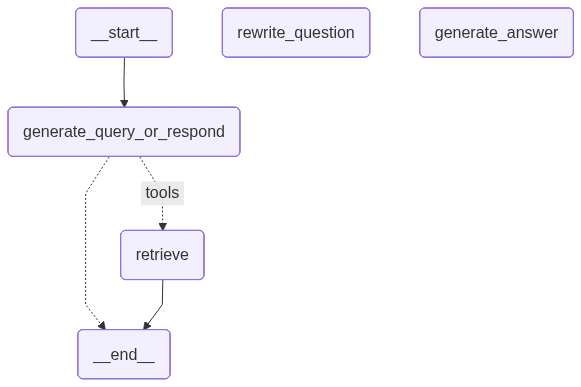

In [101]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [102]:
for chunk in graph.stream(
    {
        "messages": [
            {
                "role": "user",
                "content": "What does Lilian Weng say about types of reward hacking?",
            }
        ]
    }
):
    for node, update in chunk.items():
        print("Update from node", node)
        update["messages"][-1].pretty_print()
        print("\n\n")

Update from node generate_query_or_respond
================================== Ai Message ==================================
Tool Calls:
  retrieve_blog_posts (fc_a735e59d-a871-49b8-8c41-a63349fd5d2b)
 Call ID: fc_a735e59d-a871-49b8-8c41-a63349fd5d2b
  Args:
    query: Lilian Weng reward hacking types



Update from node retrieve
================================= Tool Message =================================
Name: retrieve_blog_posts

Citation#
Cited as:

Weng, Lilian. “Reward Hacking in Reinforcement Learning”. Lil’Log (Nov 2024). https://lilianweng.github.io/posts/2024-11-28-reward-hacking/.

Lil'Log

















|






Posts




Archive




Search




Tags




FAQ









      Reward Hacking in Reinforcement Learning
    
Date: November 28, 2024  |  Estimated Reading Time: 37 min  |  Author: Lilian Weng

author  = "Weng, Lilian",
  journal = "lilianweng.github.io",
  year    = "2024",
  month   = "Nov",
  url     = "https://lilianweng.github.io/posts/2024-11-28-reward-hacking